In [ ]:
### Darwin dataset include masks without white color (delete them)

In [73]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
from PIL import Image
import cv2
import os
from typing import Dict, List, Tuple, Optional
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt
from types import SimpleNamespace

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

In [74]:
data_dic = {
    "CVC_ClinicDB" : 0, # Colonoscopy   - 612 img / 612 mask
    "Darwin": 1,        # X-ray         - 6106 img / 6106 mask
    "DRIVE": 2,         # Fundus        - 40 img / 40 mask
    "DSB_2018": 3,      # Microscopy    - 670 img / 670 mask
    "ISIC_2018": 4,     # Dermoscopy    - 3694 img / 3694 mask
    "Montgomery": 1,    # X-ray         - 138 img / 138 mask
    "PCXA": 1,          # X-ray         - 55 img / 55 mask
    "Shenzhen" : 1,     # X-ray         - 566 img / 566 mask
    "UDIAT" : 5         # Ultrasound    - 163 img / 163 mask
}

idx_name = {
    0: "Colonoscopy",
    1: "X-ray",
    2: "Fundus",
    3: "Microscopy",
    4: "Dermoscopy",
    5: "Ultrasound"
}

In [75]:
def file_generator(folder_path = "../datasets"):
    """
    file path generator
    """
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            yield os.path.join(root, file)

In [76]:
lst = [x for x in file_generator()]
all_images = [x for x in lst if x.split("/")[-2] == "image"]
sorted_image = sorted(all_images, key=lambda x: x.split("/")[-1].split(".")[0])

all_masks = [x for x in lst if x.split("/")[-2] == "mask"]
sorted_mask = sorted(all_masks, key=lambda x: x.split("/")[-1].split(".")[0])

image_mask = list(zip(sorted_image, sorted_mask))

In [77]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def process_black_white_image(image_path, output_img = True):

    # 1. 读取图片
    img = cv2.imread(image_path)
    if img is None:
        # 尝试用PIL打开
        pil_image = Image.open(image_path)
        img = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
    
    # 2. 转换为灰度图（确保是黑白图片）
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    
    # 3. 二值化处理（确保黑白分明）
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    
    # 4. 调整尺寸为1024×1024
    binary_resized = cv2.resize(binary, (1024, 1024), interpolation=cv2.INTER_NEAREST)
    
    # 5. 找到白色区域（值大于0的像素）
    white_pixels = np.where(binary_resized > 0)
    
    if len(white_pixels[0]) == 0:
        print("图片中没有白色区域")
        print(image_path)
        return None, binary_resized
    
    # 6. 计算白色区域的边界
    y_min, y_max = np.min(white_pixels[0]), np.max(white_pixels[0])
    x_min, x_max = np.min(white_pixels[1]), np.max(white_pixels[1])
    
    # 7. 计算边界框的w, h, x, y
    w = x_max - x_min
    h = y_max - y_min
    x = x_min + w // 2  # 中心点x坐标
    y = y_min + h // 2  # 中心点y坐标
    
    # 8. 在图片上绘制矩形框（红色，线宽3像素）
    # 转换为彩色图用于绘制彩色矩形框
    if output_img:
        if len(binary_resized.shape) == 2:
            img_with_bbox = cv2.cvtColor(binary_resized, cv2.COLOR_GRAY2BGR)
        else:
            img_with_bbox = binary_resized.copy()
    
        # 绘制矩形框
        cv2.rectangle(img_with_bbox, 
                      (x_min, y_min), 
                      (x_max, y_max), 
                      (0, 0, 255),  # 红色 (BGR格式)
                      3)  # 线宽
    
        # 绘制中心点
        cv2.circle(img_with_bbox, (x, y), 5, (0, 255, 0), -1)  # 绿色中心点
        
        # 9. 保存结果
        plt.imshow(img_with_bbox)
        
        return (x, y, w, h),img_with_bbox

    else:
        output_path = ".." + "".join(image_path.split(".")[:-1]).replace("/mask/", "/box/") + ".txt"
        with open(output_path, "w") as f:
            f.write(f"{x} {y} {w} {h}")

def visualize_results(original, processed, bbox_info):
    """
    可视化结果
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # 显示原图
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original Image')
    # axes[0].axis('off')
    
    # 显示处理后的图片
    if len(processed.shape) == 2:
        axes[1].imshow(processed, cmap='gray')
    else:
        axes[1].imshow(cv2.cvtColor(processed, cv2.COLOR_BGR2RGB))
    
    x, y, w, h = bbox_info
    axes[1].set_title(f'With BBox (Center:({x},{y}), Width:{w}, Height:{h})')
    # axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()


In [70]:
## 删除空白mask

# for mask in all_masks:
#     img = cv2.imread(mask)
#     if img is None:
#         # 尝试用PIL打开
#         pil_image = Image.open(mask)
#         img = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
    
#     # 2. 转换为灰度图（确保是黑白图片）
#     if len(img.shape) == 3:
#         gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#     else:
#         gray = img
    
#     # 3. 二值化处理（确保黑白分明）
#     _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

#     if np.max(binary) == 0:
#         os.remove(mask)
#         os.remove(mask.replace("/mask/", "/image/"))

In [78]:
pbar = tqdm(all_masks, desc="Extracting Bbox for all images")
for mask in pbar:
    process_black_white_image(mask, output_img = False)

Extracting Bbox for all images: 100%|█████| 11963/11963 [04:06<00:00, 48.47it/s]


白色区域边界框：
中心点坐标: (490, 476)
宽度(w): 673 像素
高度(h): 777 像素
边界框: x_min=154, x_max=827, y_min=88, y_max=865

已保存结果图片到: result_with_bbox.png


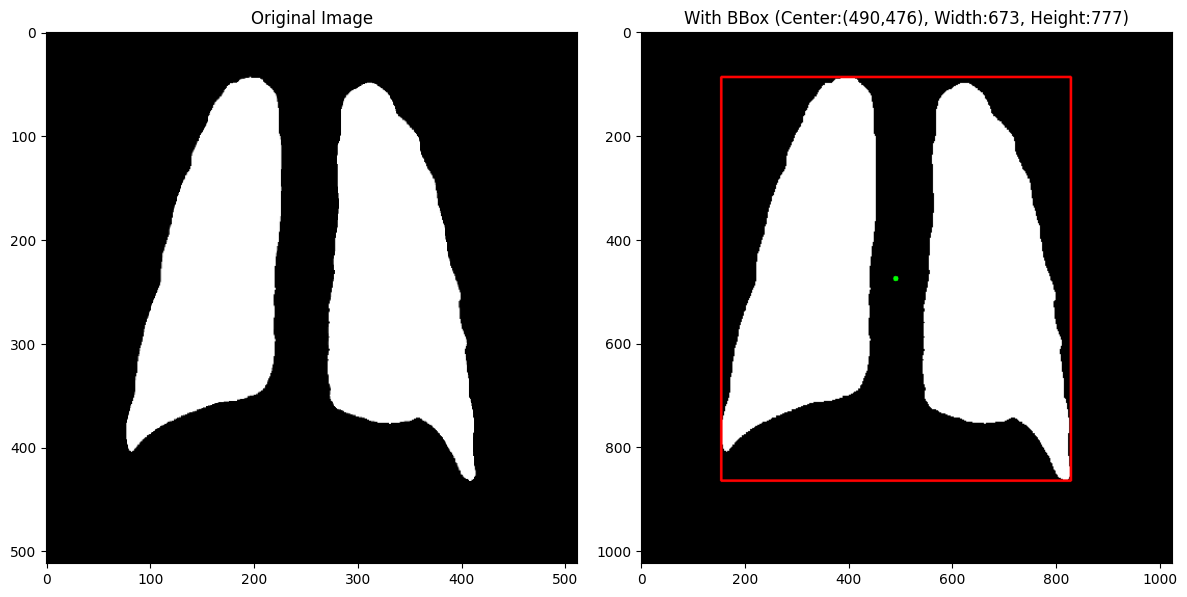


=== 最终结果 ===
边界框信息 (x, y, w, h): (np.int64(490), np.int64(476), np.int64(673), np.int64(777))
x: 490 (中心点x坐标)
y: 476 (中心点y坐标)
w: 673 (边界框宽度)
h: 777 (边界框高度)


In [30]:
bbox_info, result_image = process_black_white_image(all_masks[120], "result_with_bbox.png")

if bbox_info:
    # 读取原始图片用于可视化
    original_img = cv2.imread(all_masks[120], cv2.IMREAD_GRAYSCALE)
    
    # 可视化结果
    visualize_results(original_img, result_image, bbox_info)
    
    # 打印边界框信息
    print("\n=== 最终结果 ===")
    print(f"边界框信息 (x, y, w, h): {bbox_info}")
    print(f"x: {bbox_info[0]} (中心点x坐标)")
    print(f"y: {bbox_info[1]} (中心点y坐标)")
    print(f"w: {bbox_info[2]} (边界框宽度)")
    print(f"h: {bbox_info[3]} (边界框高度)")